[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benjamalegni/ML-luka/blob/main/04-algoritmos-geneticos/Perspectiva_Practica_Algoritmos_Geneticos.ipynb)


#Instalación de la librería

In [ ]:
!pip install geneticalgorithm

# Definición del problema y ejecución del algoritmo
Se define un cromosoma con 3 genes que pueden tomar valores entre 0 y 10.
X=(x1,x2,x3)

La función de fitness está dada por la suma de los valores de cada uno de los genes del cromosoma.
f(X)=x1+x2+x3

[[ 0 10]
 [ 0 10]
 [ 0 10]]
 The best solution found:
 [0.00444586 0.00024152 0.00161432]

 Objective function:
 0.0063017016896815825


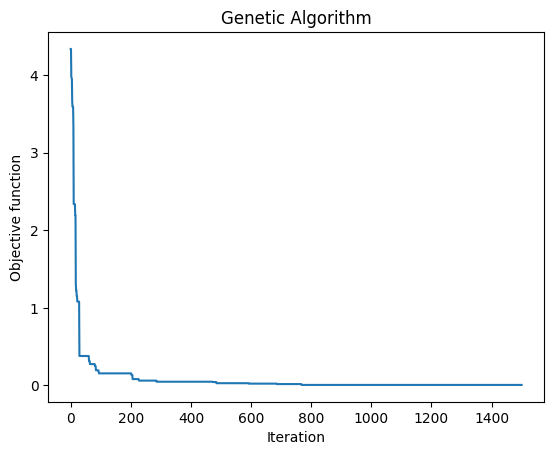

In [ ]:
import numpy as np
from geneticalgorithm import geneticalgorithm as ga

# Función de fitness
def ff(X):
    return np.sum(X) # Objetivo: minimizar la suma de los valores de cada gen. X=(x1,x2,x3) y f(X)=x1+x2+x3

# Rangos de cada gen
varbound=np.array([[0,10]]*3) # Equivalente a 3 listas
print(varbound)

# Creación del modelo
model=ga(function=ff,dimension=3,variable_type='real',variable_boundaries=varbound)

# Ejecucion del algoritmo
model.run()

Podemos acceder a los valores de la función de fitness para cada iteración y a la mejor solución hallada.

In [ ]:
print(model.report)
print(model.output_dict)

[np.float64(4.338747099866417), np.float64(4.338747099866417), np.float64(3.9813876767316025), np.float64(3.9609058749108277), np.float64(3.9554636047495317), np.float64(3.661668034534503), np.float64(3.593222668423052), np.float64(3.593222668423052), np.float64(3.593222668423052), np.float64(3.3393283119436634), np.float64(2.3378830294288058), np.float64(2.3378830294288058), np.float64(2.3378830294288058), np.float64(2.3378830294288058), np.float64(2.3378830294288058), np.float64(2.1937370659050237), np.float64(2.1937370659050237), np.float64(1.3095237818141248), np.float64(1.2263368594221569), np.float64(1.2263368594221569), np.float64(1.150160180968327), np.float64(1.150160180968327), np.float64(1.080482541897455), np.float64(1.080482541897455), np.float64(1.080482541897455), np.float64(1.080482541897455), np.float64(1.080482541897455), np.float64(1.080482541897455), np.float64(1.080482541897455), np.float64(0.37927307214349004), np.float64(0.37927307214349004), np.float64(0.3792730

#Parámetros del algoritmo

 The best solution found:
 [0.0324994  0.04218141 0.04272564]

 Objective function:
 0.11740644580282389


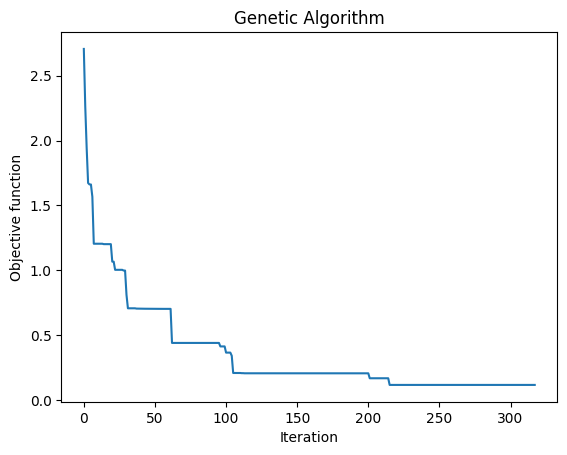

In [ ]:
import numpy as np
import time
from geneticalgorithm import geneticalgorithm as ga

# Función de fitness
def f(X):
    return np.sum(X) # Objetivo: minimizar la suma de los valores de cada gen. X=(x1,x2,x3) y f(X)=x1+x2+x3

# Rangos de cada gen
varbound=np.array([[0,10]]*3)

# Parametros del algoritmo
algorithm_param = {'max_num_iteration': None,
                   'population_size':100,
                   'mutation_probability':0.1,
                   'elit_ratio': 0.1,
                   'crossover_probability': 0.5,
                   'parents_portion': 0.3,
                   'crossover_type':'uniform',
                   'max_iteration_without_improv': 100}

# Creación del modelo
model=ga(function=f,dimension=3,variable_type='real',variable_boundaries=varbound, algorithm_parameters=algorithm_param)

ini_time = time.time()
# Ejecucion del algoritmo
model.run()

fin_time = time.time()
print("Tiempo de ejecución: ", fin_time-ini_time)


Algoritmo Genético para optimizar la elección de parámetros de un KNeighborsClassifier

Tiempo de ejecución: 3.7033114433288574 segundos
Tiempo de ejecución: 7.666253089904785 segundos
Tiempo de ejecución: 3.534167528152466 segundos
Tiempo de ejecución: 6.105452299118042 segundos
Tiempo de ejecución: 4.8257975578308105 segundos
Tiempo de ejecución: 3.8743956089019775 segundos
Tiempo de ejecución: 3.878958225250244 segundos
Tiempo de ejecución: 4.70246434211731 segundos
Tiempo de ejecución: 3.9159045219421387 segundos
Tiempo de ejecución: 3.7227165699005127 segundos
Tiempo de ejecución: 4.621013164520264 segundos
Tiempo de ejecución: 4.129122257232666 segundos
Tiempo de ejecución: 4.804040193557739 segundos
Tiempo de ejecución: 5.11533784866333 segundos
Tiempo de ejecución: 4.7281272411346436 segundos
Tiempo de ejecución: 5.064121723175049 segundos
Tiempo de ejecución: 4.732767820358276 segundos
Tiempo de ejecución: 4.966465473175049 segundos
Tiempo de ejecución: 4.538702487945557 segundos
Tiempo de ejecución: 3.768019199371338 segundos
____________________________________

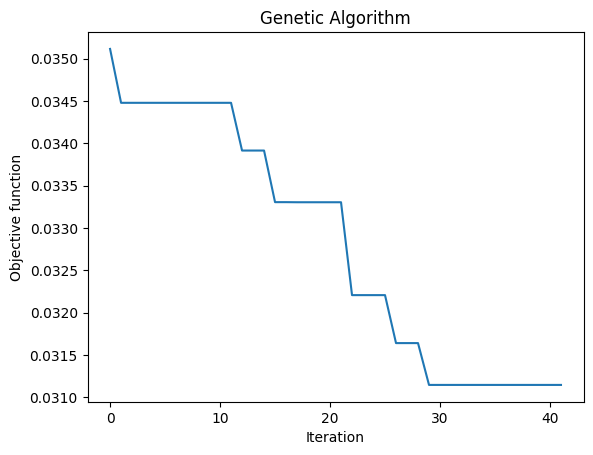


Mejor K: 3.0
Mejor weights: uniform
Mejor algorithm: kd_tree
Mejor p: 2.7596655417536455


In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier
from geneticalgorithm import geneticalgorithm as ga
import time

# Prepara los datos
data = datasets.load_digits()
X_train, y_train = data.data, data.target

# Cache para guardar los resultados ya generados
cache = {}

# Función de Fitness
def fitness_knn(X):
    #print(X)
    # Tiempo de inicio
    tiempo_inicio = time.time()
    # Extraer y mapear parámetros
    k_val = int(X[0])
    weights_idx = int(X[1])
    algorithm_idx = int(X[2])
    p = X[3]

    # Convierte a tupla para que sea hasheable, redondea para evitar problemas de precisión
    cromosoma_id = tuple(np.round(X, 6))
    if cromosoma_id in cache:
        tiempo_fin = time.time()
        tiempo_ejecucion = tiempo_fin - tiempo_inicio
        print(f"Tiempo de ejecución cache: {tiempo_ejecucion} segundos")
        return cache[cromosoma_id] # retorna el valor almacenado si ya fue evaluado

    weights = ['uniform', 'distance']
    algorithms = ['ball_tree', 'kd_tree', 'brute']
    selected_weights = weights[weights_idx]
    selected_algorithm = algorithms[algorithm_idx]

    # Crea el modelo con los parámetros del individuo
    model = KNeighborsClassifier(n_neighbors=k_val, weights=selected_weights, algorithm=selected_algorithm, p=p)

    # Evalua usando Cross-Validation
    scoring = ['f1_macro']
    scores = cross_validate(model, X_train, y_train, scoring=scoring, cv=4) # , n_jobs=-1

    f1 = scores['test_f1_macro'].mean()
    cache[cromosoma_id] = 1 - f1

    tiempo_fin = time.time()
    tiempo_ejecucion = tiempo_fin - tiempo_inicio
    print(f"Tiempo de ejecución: {tiempo_ejecucion} segundos")

    return 1 - f1

# Define cromosomas y límites [Min, Max]
# X0: n_neighbors, X1: weights, X2: algorithm, X3: p value
varbound = np.array([
    [1, 100],
    [0, 1],
    [0, 2],
    [1, 5]
])

#  Configura y corre el AG
var_types = np.array(['int', 'int', 'int', 'real'])

parametros = {'max_num_iteration': None,
      	      'population_size': 20,
	 	          'mutation_probability': 0.2,
      	      'elit_ratio': 0.01,
      	      'crossover_probability': 0.5,
      	      'parents_portion': 0.3,
	 	          'crossover_type': 'uniform',
	 	          'max_iteration_without_improv':10}

model = ga(function=fitness_knn,
           dimension=4,
           variable_type_mixed=var_types,
           variable_boundaries=varbound,
           algorithm_parameters=parametros)

model.run()

# 5. Resultados
best_params = model.output_dict['variable']
print(f"\nMejor K: {best_params[0]}")
print(f"Mejor weights: {['uniform', 'distance'][int(best_params[1])]}")
print(f"Mejor algorithm: {['ball_tree', 'kd_tree', 'brute'][int(best_params[2])]}")
print(f"Mejor p: {best_params[3]}")